In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r'C:\Users\Mario\OneDrive\Desktop\SummerTraining\HOUSEHOLD POWER CONSUMPTION\household_power_consumption.txt', sep=';', low_memory=False, na_values=['?'])
# path varies from device to another

In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [5]:
df.shape

(2075259, 9)

In [6]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [7]:
df.duplicated().sum()
df=df.drop_duplicates() #no need btw

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


In [9]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


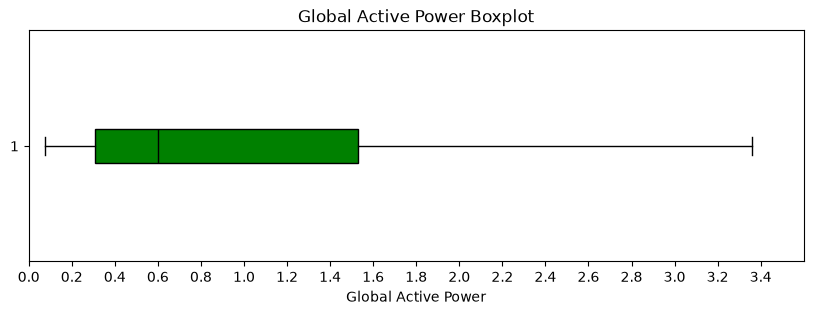

In [10]:
import matplotlib.pyplot as plt
import numpy as np

data = df['Global_active_power'].dropna()

plt.figure(figsize=(10, 3))

plt.boxplot(
    data,
    orientation='horizontal',
    patch_artist=True,
    showfliers=False,   
    boxprops=dict(facecolor='green'),
    medianprops=dict(color='black'))
   # flierprops=dict(marker='o', markerfacecolor='red', markersize=7))   no need for it too many data 


plt.title('Global Active Power Boxplot')
plt.xlabel('Global Active Power')
plt.xlim(0, 12)
plt.xlim(0, 3.6)
plt.xticks(np.arange(0, 3.6, 0.2))

plt.show()

In [11]:
q1=df['Global_active_power'].quantile(0.25)
q3=df['Global_active_power'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr


df['Global_active_power']=df['Global_active_power'].clip(lower=lower_bound, upper=upper_bound)

In [12]:
outliers = df[
    (df['Global_active_power'] < lower_bound) |
    (df['Global_active_power'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


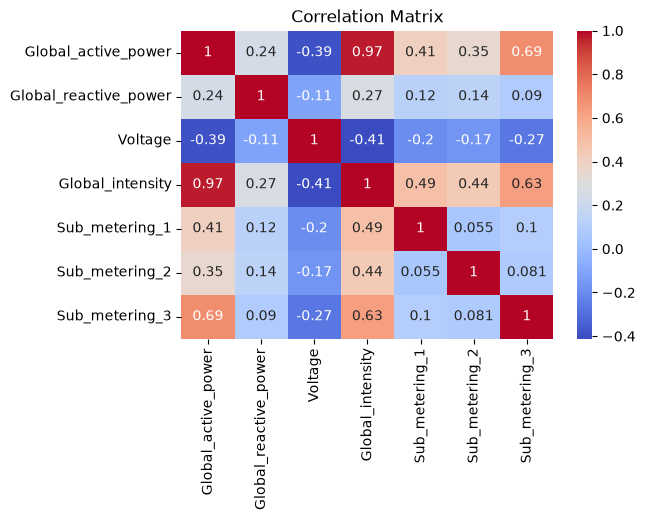

In [13]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

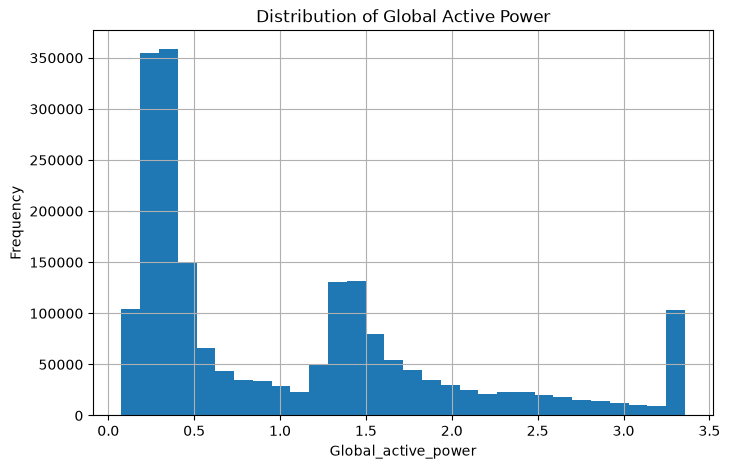

In [14]:
plt.figure(figsize=(8,5))
df['Global_active_power'].hist(bins=30)

plt.title('Distribution of Global Active Power')
plt.xlabel('Global_active_power')
plt.ylabel('Frequency')
plt.show()

In [15]:
df['Global_active_power'] = df['Global_active_power'].fillna(
    df['Global_active_power'].mean()
)

In [16]:
df['Global_active_power'].isnull().sum()

np.int64(0)

In [17]:
columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for column in columns:
    df[column] = df[column].fillna(df[column].mean())

In [18]:
df[columns].isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [24]:
features = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

temp_df = df[features].describe().T

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(temp_df)

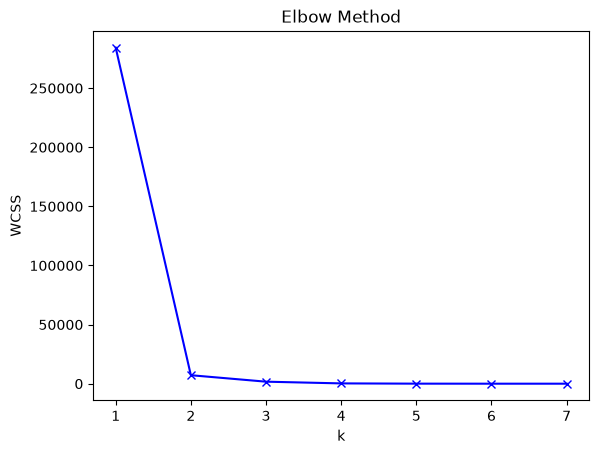

In [36]:
# Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(temp_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 8), wcss, 'bx-')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [38]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

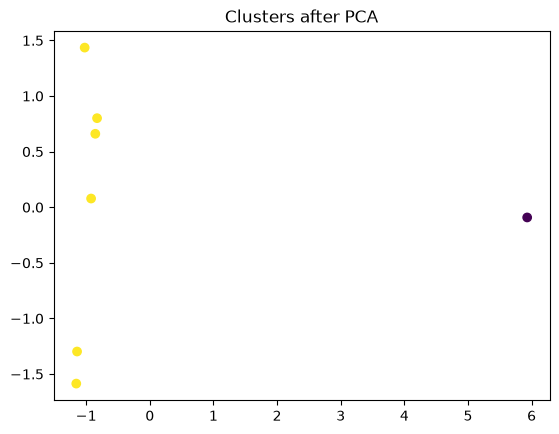

In [44]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("Clusters after PCA")
plt.show()

In [47]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled)

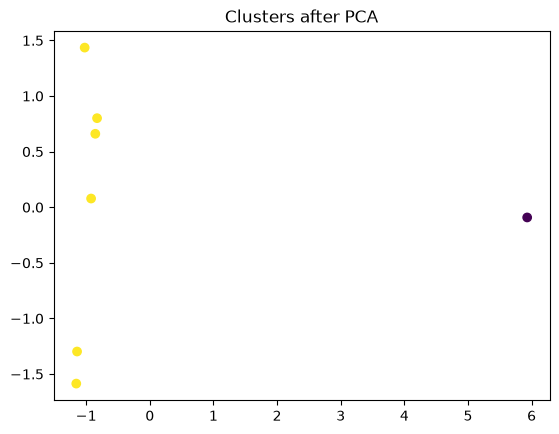

In [48]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("Clusters after PCA")
plt.show()